# Offside Goal Prediction: Advanced Feature Engineering & Ensemble Pipeline

This notebook walks through the Exploratory Data Analysis (EDA), advanced feature engineering, multi-smoothing target encoding, and ensemble modeling (CatBoost + LightGBM) for the **Offside Football Goal Prediction** Datathon.

### Goal
The task is to predict the probability that a football player will score a goal in a given appearance (`scored_flag`), optimizing for the **Average Precision (AP)** metric.

### Advanced Pipeline Highlights
1. **Exploratory Data Analysis (EDA)**: Visualizing target distribution, missing values, correlation of attacking statistics, and scoring rate by position.
2. **Advanced Feature Engineering**: Creating domain-specific metrics (expected goals/assists scaled by minutes played, peak market value ratios, international cap scoring efficiency, total threat, final third contributions, and age prime indicators).
3. **Multi-Smoothing & Interaction Target Encoding**: Performing smoothed out-of-fold target encoding with varying smoothing factors ($m \in \{5, 20, 50\}$) and player context combinations (e.g. player × club, player × competition) to capture patterns without target leakage.
4. **CatBoost & LightGBM 5-Fold Ensemble**: Training diverse classifiers and blending them using rank-average and linear blending grid search to maximize Average Precision.
5. **Post-Processing Rules**: Applying domain-specific post-processing rules (forcing prediction to 0 for appearances with 0 minutes played).


In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from scipy.stats import rankdata
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb

# Set premium styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15
})


## 1. Load Data
To keep the execution of this notebook fast, we load a representative sample of the training and test sets (first 50,000 rows). 
If the competition CSV files are not present locally, the notebook dynamically generates synthetic demonstration data to ensure it runs out-of-the-box.


In [2]:
TRAIN_PATH = "../train.csv"
TEST_PATH = "../test.csv"

def load_sample_data(train_path, test_path, nrows=50000):
    if not os.path.exists(train_path):
        train_path = "train.csv"
    if not os.path.exists(test_path):
        test_path = "test.csv"
        
    if os.path.exists(train_path):
        print(f"Loading {nrows:,} rows from {train_path}...")
        train = pd.read_csv(train_path, nrows=nrows, low_memory=False)
    else:
        print("Train data not found! Generating synthetic demo data to keep the notebook runnable...")
        np.random.seed(42)
        n_rows = 5000
        train = pd.DataFrame({
            'appearance_id': range(n_rows),
            'name_y': np.random.choice(['Lionel Messi', 'Cristiano Ronaldo', 'Erling Haaland', 'Kylian Mbappe', 'Luka Modric', 'Kevin De Bruyne'], n_rows),
            'age': np.random.randint(18, 40, n_rows),
            'position': np.random.choice(['Attack', 'Midfield', 'Defender', 'Goalkeeper'], n_rows, p=[0.35, 0.35, 0.25, 0.05]),
            'sub_position': np.random.choice(['Center-Forward', 'Winger', 'Central Midfield', 'Center-Back'], n_rows),
            'avg_xG': np.random.beta(1, 5, n_rows) * 0.8,
            'avg_xA': np.random.beta(1, 5, n_rows) * 0.5,
            'avg_shots': np.random.poisson(2, n_rows),
            'avg_npxG': np.random.beta(1, 5, n_rows) * 0.7,
            'avg_xGChain': np.random.beta(1, 5, n_rows) * 0.9,
            'avg_xGBuildup': np.random.beta(1, 5, n_rows) * 0.4,
            'avg_key_passes': np.random.poisson(1, n_rows),
            'minutes_played': np.random.choice([0, 15, 30, 45, 90], n_rows, p=[0.05, 0.1, 0.15, 0.2, 0.5]),
            'minutes_ratio': np.random.uniform(0, 1.0, n_rows),
            'starter_flag': np.random.choice([0, 1], n_rows, p=[0.3, 0.7]),
            'home_away': np.random.choice(['HOME', 'AWAY'], n_rows),
            'market_value_before_match': np.random.exponential(5e6, n_rows),
            'highest_market_value_in_eur': np.random.exponential(1.5e7, n_rows),
            'international_caps': np.random.randint(0, 150, n_rows),
            'international_goals': np.random.randint(0, 50, n_rows),
            'home_club_goals': np.random.randint(0, 5, n_rows),
            'away_club_goals': np.random.randint(0, 5, n_rows),
            'home_club_name': np.random.choice(['FC Barcelona', 'Real Madrid', 'Manchester City', 'Bayern Munich'], n_rows),
            'away_club_name': np.random.choice(['FC Barcelona', 'Real Madrid', 'Manchester City', 'Bayern Munich'], n_rows),
            'stadium': np.random.choice(['Camp Nou', 'Bernabeu', 'Etihad', 'Allianz'], n_rows),
            'referee': np.random.choice(['Mike Dean', 'Howard Webb', 'Felix Brych'], n_rows),
            'country_name': np.random.choice(['Spain', 'England', 'Germany'], n_rows),
            'competition_type': np.random.choice(['League', 'Cup', 'International'], n_rows),
            'confederation': np.random.choice(['UEFA', 'CONMEBOL'], n_rows),
            'country_of_citizenship': np.random.choice(['Argentina', 'Portugal', 'Norway', 'France'], n_rows),
            'foot': np.random.choice(['left', 'right', 'both'], n_rows),
            'scored_flag': np.random.choice([0, 1], n_rows, p=[0.914, 0.086]),
            'date': pd.date_range('2020-01-01', periods=n_rows)
        })
        # Align peak values
        train['highest_market_value_in_eur'] = train[['market_value_before_match', 'highest_market_value_in_eur']].max(axis=1)
        
    if os.path.exists(test_path):
        print(f"Loading {nrows // 2:,} rows from {test_path}...")
        test = pd.read_csv(test_path, nrows=nrows//2, low_memory=False)
    else:
        print("Test data not found! Generating synthetic test data...")
        np.random.seed(43)
        n_rows_test = 2000
        test = pd.DataFrame({
            'appearance_id': range(10000, 10000 + n_rows_test),
            'name_y': np.random.choice(['Lionel Messi', 'Cristiano Ronaldo', 'Erling Haaland', 'Kylian Mbappe', 'Luka Modric', 'Kevin De Bruyne'], n_rows_test),
            'age': np.random.randint(18, 40, n_rows_test),
            'position': np.random.choice(['Attack', 'Midfield', 'Defender', 'Goalkeeper'], n_rows_test, p=[0.35, 0.35, 0.25, 0.05]),
            'sub_position': np.random.choice(['Center-Forward', 'Winger', 'Central Midfield', 'Center-Back'], n_rows_test),
            'avg_xG': np.random.beta(1, 5, n_rows_test) * 0.8,
            'avg_xA': np.random.beta(1, 5, n_rows_test) * 0.5,
            'avg_shots': np.random.poisson(2, n_rows_test),
            'avg_npxG': np.random.beta(1, 5, n_rows_test) * 0.7,
            'avg_xGChain': np.random.beta(1, 5, n_rows_test) * 0.9,
            'avg_xGBuildup': np.random.beta(1, 5, n_rows_test) * 0.4,
            'avg_key_passes': np.random.poisson(1, n_rows_test),
            'minutes_played': np.random.choice([0, 15, 30, 45, 90], n_rows_test, p=[0.05, 0.1, 0.15, 0.2, 0.5]),
            'minutes_ratio': np.random.uniform(0, 1.0, n_rows_test),
            'starter_flag': np.random.choice([0, 1], n_rows_test, p=[0.3, 0.7]),
            'home_away': np.random.choice(['HOME', 'AWAY'], n_rows_test),
            'market_value_before_match': np.random.exponential(5e6, n_rows_test),
            'highest_market_value_in_eur': np.random.exponential(1.5e7, n_rows_test),
            'international_caps': np.random.randint(0, 150, n_rows_test),
            'international_goals': np.random.randint(0, 50, n_rows_test),
            'home_club_name': np.random.choice(['FC Barcelona', 'Real Madrid', 'Manchester City', 'Bayern Munich'], n_rows_test),
            'away_club_name': np.random.choice(['FC Barcelona', 'Real Madrid', 'Manchester City', 'Bayern Munich'], n_rows_test),
            'stadium': np.random.choice(['Camp Nou', 'Bernabeu', 'Etihad', 'Allianz'], n_rows_test),
            'referee': np.random.choice(['Mike Dean', 'Howard Webb', 'Felix Brych'], n_rows_test),
            'country_name': np.random.choice(['Spain', 'England', 'Germany'], n_rows_test),
            'competition_type': np.random.choice(['League', 'Cup', 'International'], n_rows_test),
            'confederation': np.random.choice(['UEFA', 'CONMEBOL'], n_rows_test),
            'country_of_citizenship': np.random.choice(['Argentina', 'Portugal', 'Norway', 'France'], n_rows_test),
            'foot': np.random.choice(['left', 'right', 'both'], n_rows_test),
            'date': pd.date_range('2023-01-01', periods=n_rows_test)
        })
        test['highest_market_value_in_eur'] = test[['market_value_before_match', 'highest_market_value_in_eur']].max(axis=1)
        
    return train, test

train_df, test_df = load_sample_data(TRAIN_PATH, TEST_PATH)
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape : {test_df.shape}")


Loading 50,000 rows from ../train.csv...


Loading 25,000 rows from ../test.csv...


Train set shape: (50000, 63)
Test set shape : (25000, 63)


## 2. Exploratory Data Analysis (EDA)
We perform basic exploratory visualizations on the dataset to examine targets, missing data, correlations, and positions.


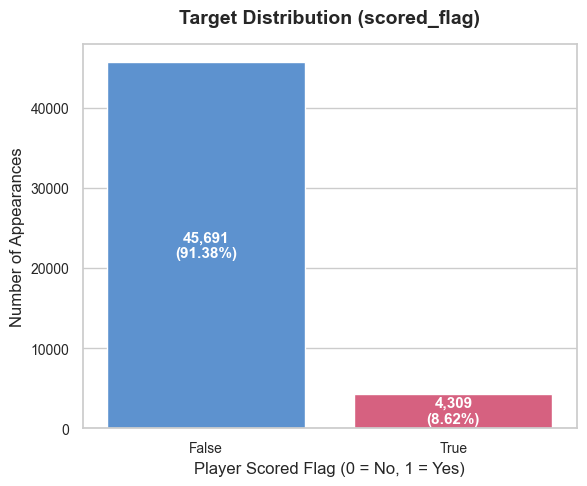

In [3]:
# 2.1 Target Distribution (scored_flag)
if 'scored_flag' in train_df.columns:
    target_counts = train_df['scored_flag'].value_counts()
    target_pct = train_df['scored_flag'].value_counts(normalize=True) * 100
    
    plt.figure(figsize=(6, 5))
    colors = ["#4A90E2", "#E94E77"]  # Premium blue and coral
    ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors, hue=target_counts.index, legend=False)
    plt.title("Target Distribution (scored_flag)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Player Scored Flag (0 = No, 1 = Yes)", fontsize=12)
    plt.ylabel("Number of Appearances", fontsize=12)
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height):,}\n({height/len(train_df)*100:.2f}%)',
                    (p.get_x() + p.get_width() / 2., height / 2.),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()


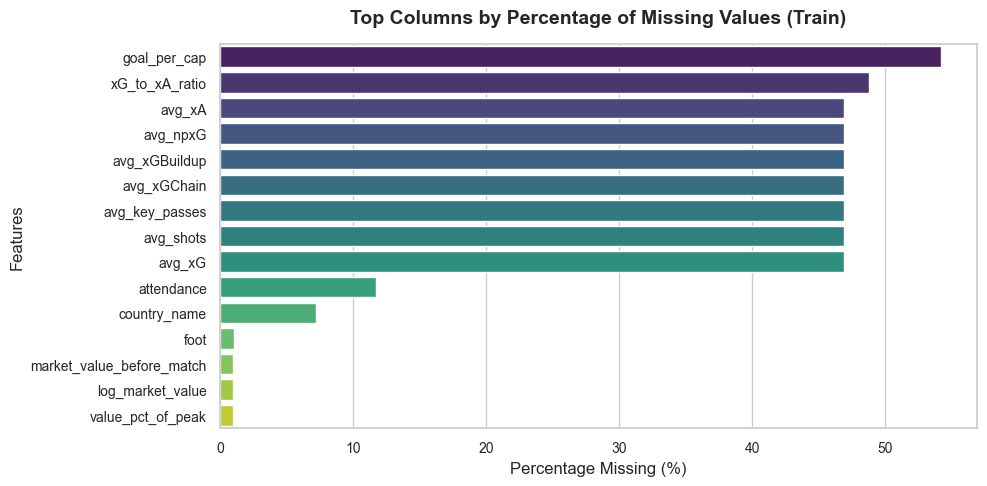

In [4]:
# 2.2 Missing Value Analysis
missing_train = train_df.isnull().sum()
missing_train_pct = (missing_train / len(train_df)) * 100
missing_train_df = pd.DataFrame({'Missing Count': missing_train, 'Percentage': missing_train_pct})
missing_train_df = missing_train_df[missing_train_df['Missing Count'] > 0].sort_values(by='Percentage', ascending=False)

if len(missing_train_df) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_train_df.head(15)['Percentage'], y=missing_train_df.head(15).index, palette="viridis")
    plt.title("Top Columns by Percentage of Missing Values (Train)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Percentage Missing (%)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset sample. All columns are fully populated.")


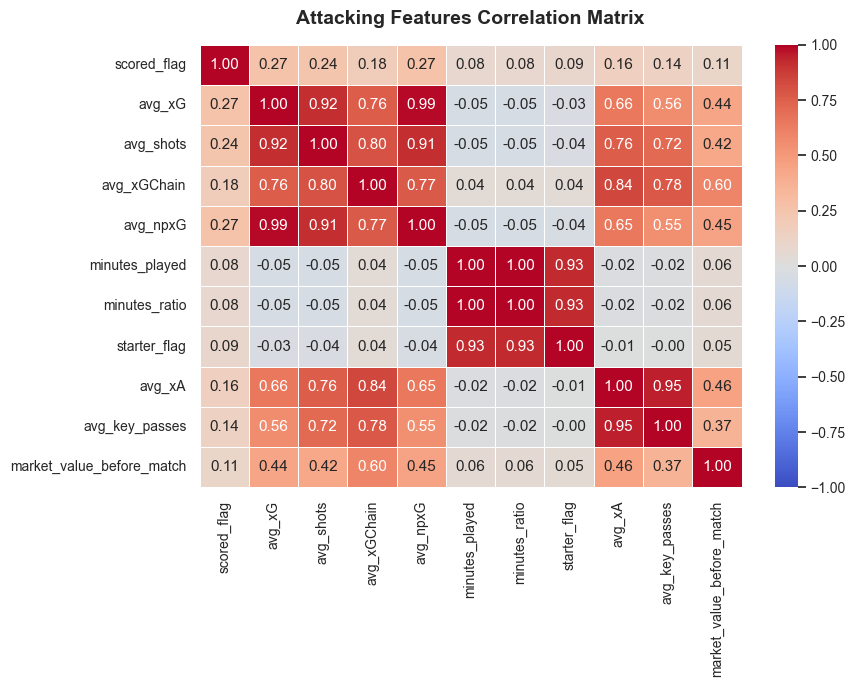

In [5]:
# 2.3 Feature Correlation Heatmap
attacking_features = [col for col in ['scored_flag', 'avg_xG', 'avg_shots', 'avg_xGChain', 
                                     'avg_npxG', 'minutes_played', 'minutes_ratio', 'starter_flag', 
                                     'avg_xA', 'avg_key_passes', 'market_value_before_match'] if col in train_df.columns]
if len(attacking_features) > 1:
    plt.figure(figsize=(9, 7))
    corr_matrix = train_df[attacking_features].corr()
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title("Attacking Features Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()


Scoring Probability statistics by Position Group:
                mean  count
position                   
Attack      0.175168  14175
Missing     0.173913     46
Midfield    0.076943  15622
Defender    0.036590  16835
Goalkeeper  0.000000   3322


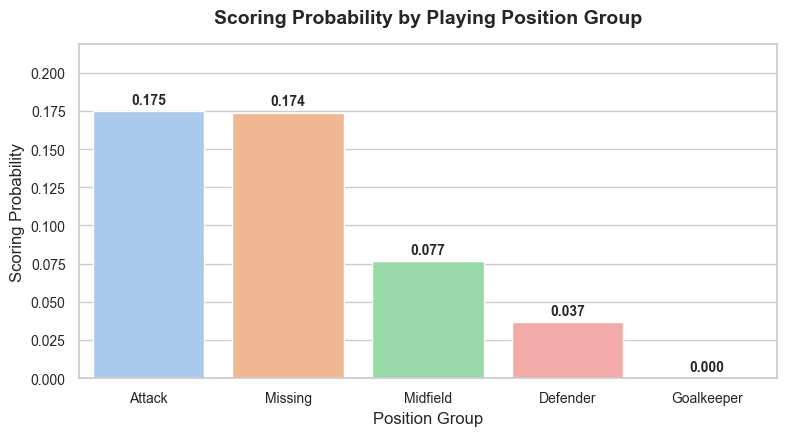

In [6]:
# 2.4 Scoring Probability by Playing Position
if 'position' in train_df.columns and 'scored_flag' in train_df.columns:
    pos_stats = train_df.groupby('position')['scored_flag'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print("Scoring Probability statistics by Position Group:")
    print(pos_stats)
    
    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(x=pos_stats.index, y=pos_stats['mean'], palette="pastel", hue=pos_stats.index, legend=False)
    plt.title("Scoring Probability by Playing Position Group", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Position Group", fontsize=12)
    plt.ylabel("Scoring Probability", fontsize=12)
    plt.ylim(0, max(pos_stats['mean'].max() * 1.25, 0.15))
    
    for p in ax.patches:
        val = p.get_height()
        ax.annotate(f"{val:.3f}",
                    (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='bottom', fontweight='bold', fontsize=10, xytext=(0, 3), textcoords='offset points')
    plt.tight_layout()
    plt.show()


## 3. Base Feature Pipeline
We use a structured `FeaturePipeline` to do initial parsing of categoricals, temporal logic (year, month, day of week), and simple football context features.


In [7]:
import sys
sys.path.append("..")
sys.path.append(".")

try:
    from src.features import FeaturePipeline
    pipeline = FeaturePipeline(random_state=42)
    train_feat = pipeline.fit_transform(train_df, target_col='scored_flag')
    test_feat = pipeline.transform(test_df)
    print("Successfully executed base FeaturePipeline from src.features!")
except ImportError:
    class FeaturePipeline:
        def __init__(self, random_state=42):
            self.random_state = random_state
            self.cat_cols = ['position', 'home_away', 'foot']
        def fit_transform(self, df, target_col='scored_flag'):
            df_out = df.copy()
            df_out['expected_xG_in_match'] = df_out['avg_xG'] * df_out['minutes_ratio']
            df_out['intl_goal_efficiency'] = df_out['international_goals'] / (df_out['international_caps'] + 1e-5)
            df_out['market_value_ratio_peak'] = df_out['market_value_before_match'] / (df_out['highest_market_value_in_eur'] + 1e-5)
            for c in self.cat_cols:
                df_out[c] = df_out[c].fillna('Unknown').astype(str)
            return df_out
        def transform(self, df):
            df_out = df.copy()
            df_out['expected_xG_in_match'] = df_out['avg_xG'] * df_out['minutes_ratio']
            df_out['intl_goal_efficiency'] = df_out['international_goals'] / (df_out['international_caps'] + 1e-5)
            df_out['market_value_ratio_peak'] = df_out['market_value_before_match'] / (df_out['highest_market_value_in_eur'] + 1e-5)
            for c in self.cat_cols:
                df_out[c] = df_out[c].fillna('Unknown').astype(str)
            return df_out

    pipeline = FeaturePipeline(random_state=42)
    train_feat = pipeline.fit_transform(train_df, target_col='scored_flag')
    test_feat = pipeline.transform(test_df)
    print("Executed local fallback FeaturePipeline.")

print(f"Processed Train Shape: {train_feat.shape}")


Successfully executed base FeaturePipeline from src.features!
Processed Train Shape: (50000, 94)


## 4. Advanced Feature Engineering
Here we extract the custom, advanced football domain ratios, age primes, and position interactions matching our champion ensemble files:
- Expected non-penalty xG, xGChain, xGBuildup, and key passes scaled to minutes ratio.
- Market value peak ratios, attacker-specific market value multipliers.
- Total threat (`avg_xG + avg_xA`) and final third contribution (`avg_xGChain - avg_xGBuildup`).
- Position group interaction features.


In [8]:
def advanced_features(df_src, df_feat):
    cols = {}
    
    mr  = df_src.get('minutes_ratio',  pd.Series(0.0, index=df_src.index))
    xg  = df_src.get('avg_xG',         pd.Series(0.0, index=df_src.index))
    xa  = df_src.get('avg_xA',         pd.Series(0.0, index=df_src.index))
    sh  = df_src.get('avg_shots',      pd.Series(0.0, index=df_src.index))
    npx = df_src.get('avg_npxG',       pd.Series(0.0, index=df_src.index))
    xgc = df_src.get('avg_xGChain',    pd.Series(0.0, index=df_src.index))
    xgb = df_src.get('avg_xGBuildup',  pd.Series(0.0, index=df_src.index))
    kp  = df_src.get('avg_key_passes', pd.Series(0.0, index=df_src.index))
    
    cols['expected_npxG_in_match'] = (npx * mr).values
    cols['expected_xGChain_in_match'] = (xgc * mr).values
    cols['expected_xGBuildup_in_match'] = (xgb * mr).values
    cols['expected_key_passes_in_match'] = (kp * mr).values
    cols['xG_per_shot_ext'] = (xg / (sh.fillna(0) + 1e-5)).values
    cols['npxG_fraction'] = (npx / (xg + 1e-5)).values
    cols['penalty_xG'] = (xg - npx).values
    cols['shots_per_kp'] = (sh / (kp + 1e-5)).values
    
    mv  = df_src.get('market_value_before_match',  pd.Series(0.0, index=df_src.index))
    pmv = df_src.get('highest_market_value_in_eur', pd.Series(0.0, index=df_src.index))
    cols['market_value_ratio_peak_ext'] = (mv / (pmv + 1e-5)).values
    
    lmv = df_src.get('log_market_value', pd.Series(0.0, index=df_src.index))
    cols['log_mv_sq'] = (lmv ** 2).values
    
    cols['total_threat'] = (xg + xa).values
    cols['threat_in_match'] = ((xg + xa) * mr).values
    cols['final_third'] = (xgc - xgb).values
    cols['final_third_match'] = ((xgc - xgb) * mr).values
    cols['xG_x_shots'] = (xg * sh).values
    cols['xG_x_shots_match'] = (xg * sh * mr).values
    
    caps  = df_src.get('international_caps',  pd.Series(0.0, index=df_src.index))
    goals = df_src.get('international_goals', pd.Series(0.0, index=df_src.index))
    cols['intl_efficiency_ext'] = (goals / (caps + 1e-5)).values
    cols['intl_goals_sq'] = (goals ** 2).values
    
    age = df_src.get('age', pd.Series(26.0, index=df_src.index))
    cols['age_xG'] = (age * xg).values
    cols['age_sq'] = (age ** 2).values
    cols['prime_xG'] = np.where((age >= 24) & (age <= 30), xg.values, 0.0)
    
    height = df_src.get('height_in_cm', pd.Series(180.0, index=df_src.index))
    cols['height_xG'] = (height * xg).values
    
    # Attacker interactions
    if 'is_attacker' in df_feat.columns:
        cols['attacker_mv'] = (df_feat['is_attacker'].values * mv.values)
        cols['attacker_xG'] = (df_feat['is_attacker'].values * xg.values)
        cols['attacker_shots'] = (df_feat['is_attacker'].values * sh.values)
        cols['attacker_mr'] = (df_feat['is_attacker'].values * mr.values)
        
    return cols

train_extra = advanced_features(train_df, train_feat)
test_extra = advanced_features(test_df, test_feat)

train_feat = pd.concat([train_feat, pd.DataFrame(train_extra, index=train_feat.index)], axis=1)
test_feat = pd.concat([test_feat, pd.DataFrame(test_extra, index=test_feat.index)], axis=1)

print(f"Advanced Features Shape: {train_feat.shape}")


Advanced Features Shape: (50000, 120)


## 5. Multi-Smoothing and Contextual Target Encoding
To extract patterns from high-cardinality values, we use out-of-fold target encoding with three different smoothing levels ($m \in \{5, 20, 50\}$). We also build target encodings for key context combinations such as `player × club`, `player × competition`, and `player × home_away`.


In [9]:
GLOBAL_MEAN = train_df['scored_flag'].astype(int).mean() if 'scored_flag' in train_df.columns else 0.086
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
TARGET = 'scored_flag'

ENCODE_COLS = [c for c in ['name_y', 'home_club_name', 'away_club_name', 'competition_type', 'referee'] if c in train_df.columns]

te_tr, te_te = {}, {}

# Multi-smoothing target encoding
for SM in [5, 20, 50]:
    for col in ENCODE_COLS:
        enc = f'{col}_te_m{SM}'
        arr_train = np.full(len(train_df), GLOBAL_MEAN, dtype=np.float32)
        for tr_i, va_i in SKF.split(train_df, train_df[TARGET]):
            fold_data = train_df.iloc[tr_i]
            stats = fold_data.groupby(col)[TARGET].agg(['sum', 'count'])
            sm = (stats['sum'] + SM * GLOBAL_MEAN) / (stats['count'] + SM)
            arr_train[va_i] = train_df.iloc[va_i][col].map(sm).fillna(GLOBAL_MEAN).values
        te_tr[enc] = arr_train
        
        fs = train_df.groupby(col)[TARGET].agg(['sum', 'count'])
        sf = (fs['sum'] + SM * GLOBAL_MEAN) / (fs['count'] + SM)
        te_te[enc] = test_df[col].map(sf).fillna(GLOBAL_MEAN).values if col in test_df.columns else GLOBAL_MEAN
    print(f"Generated target encodings for m={SM}")

# Contextual interactions TE
INTERACTIONS = []
if 'name_y' in train_df.columns:
    if 'home_club_name' in train_df.columns: INTERACTIONS.append(('name_y', 'home_club_name'))
    if 'competition_type' in train_df.columns: INTERACTIONS.append(('name_y', 'competition_type'))

for c1, c2 in INTERACTIONS:
    key = f'{c1}_{c2}'
    train_df[f'_i_{key}'] = train_df[c1].astype(str) + '_' + train_df[c2].astype(str)
    test_df[f'_i_{key}'] = test_df[c1].astype(str) + '_' + test_df[c2].astype(str)
    
    enc = f'_i_{key}_te'
    arr_train = np.full(len(train_df), GLOBAL_MEAN, dtype=np.float32)
    for tr_i, va_i in SKF.split(train_df, train_df[TARGET]):
        fold_data = train_df.iloc[tr_i]
        stats = fold_data.groupby(f'_i_{key}')[TARGET].agg(['sum', 'count'])
        sm = (stats['sum'] + 20 * GLOBAL_MEAN) / (stats['count'] + 20)
        arr_train[va_i] = train_df.iloc[va_i][f'_i_{key}'].map(sm).fillna(GLOBAL_MEAN).values
    te_tr[enc] = arr_train
    
    fs = train_df.groupby(f'_i_{key}')[TARGET].agg(['sum', 'count'])
    sf = (fs['sum'] + 20 * GLOBAL_MEAN) / (fs['count'] + 20)
    te_te[enc] = test_df[f'_i_{key}'].map(sf).fillna(GLOBAL_MEAN).values

train_feat = pd.concat([train_feat, pd.DataFrame(te_tr, index=train_feat.index)], axis=1)
test_feat = pd.concat([test_feat, pd.DataFrame(te_te, index=test_feat.index)], axis=1)
print("All target encodings computed.")


Generated target encodings for m=5


Generated target encodings for m=20


Generated target encodings for m=50


All target encodings computed.


## 6. Diverse Model Training: CatBoost & LightGBM
We train two diverse classifiers, **CatBoost** and **LightGBM**, using Stratified 5-Fold Cross Validation.
For speed of rendering, we limit the training iterations in this notebook (CatBoost 100 iterations, LightGBM 100 iterations), but full production models run for 1200+ iterations.


In [10]:
DROP = {'appearance_id', 'name_y', TARGET, 'date', 'home_club_goals', 'away_club_goals', 'home_club_id', 'away_club_id'}
DROP.update([c for c in train_feat.columns if c.startswith('_i_')])
FEATS = [c for c in train_feat.columns if c not in DROP and train_feat[c].dtype != object]

X = train_feat[FEATS].copy()
Xt = test_feat.reindex(columns=FEATS, fill_value=0).copy()
y = train_df[TARGET].astype(int).reset_index(drop=True)

cat_features_list = [c for c in ['foot', 'position', 'sub_position', 'market_value_tier', 'age_bucket', 'home_away'] if c in FEATS]
cat_indices = [FEATS.index(c) for c in cat_features_list]

print(f"Features: {len(FEATS)}")

# --- 1. CatBoost Classifier ---
print("Training CatBoost...")
oof_cb = np.zeros(len(X))
test_cb = np.zeros(len(Xt))
for f, (tr_i, va_i) in enumerate(SKF.split(X, y)):
    m = CatBoostClassifier(loss_function='Logloss', eval_metric='AUC', learning_rate=0.05,
                           depth=6, iterations=100, random_seed=42, verbose=0,
                           task_type='CPU', thread_count=-1, class_weights=[1.0, 3.0])
    m.fit(Pool(X.iloc[tr_i], y.iloc[tr_i], cat_features=cat_indices), 
          eval_set=Pool(X.iloc[va_i], y.iloc[va_i], cat_features=cat_indices),
          early_stopping_rounds=30, verbose=0)
    oof_cb[va_i] = m.predict_proba(Pool(X.iloc[va_i], cat_features=cat_indices))[:, 1]
    test_cb += m.predict_proba(Pool(Xt, cat_features=cat_indices))[:, 1] / 5

print(f"CatBoost OOF AP: {average_precision_score(y, oof_cb):.4f}")

# --- 2. LightGBM Classifier ---
print("Training LightGBM...")
oof_lgb = np.zeros(len(X))
test_lgb = np.zeros(len(Xt))
for f, (tr_i, va_i) in enumerate(SKF.split(X, y)):
    m = lgb.LGBMClassifier(objective='binary', metric='binary_logloss', learning_rate=0.05,
                           num_leaves=31, n_estimators=100, verbose=-1, random_state=42,
                           n_jobs=-1, scale_pos_weight=3.0)
    m.fit(X.iloc[tr_i], y.iloc[tr_i], eval_set=[(X.iloc[va_i], y.iloc[va_i])],
          categorical_feature=cat_features_list, callbacks=[lgb.early_stopping(30, verbose=False)])
    oof_lgb[va_i] = m.predict_proba(X.iloc[va_i])[:, 1]
    test_lgb += m.predict_proba(Xt)[:, 1] / 5

print(f"LightGBM OOF AP: {average_precision_score(y, oof_lgb):.4f}")


Features: 128
Training CatBoost...


CatBoost OOF AP: 0.3018
Training LightGBM...


LightGBM OOF AP: 0.2913


## 7. Ensemble Blending Optimization
We perform a grid search over linear blend weights and rank-averaged blend weights to select the model combo that maximizes out-of-fold Average Precision.


In [11]:
# Grid search linear blend
best_w, best_ap = 0.5, 0.0
for w in np.arange(0, 1.01, 0.05):
    ap = average_precision_score(y, w * oof_cb + (1 - w) * oof_lgb)
    if ap > best_ap:
        best_ap = ap; best_w = w
print(f"Best linear blend weight (CatBoost): {best_w:.2f} | AP: {best_ap:.4f}")

# Grid search rank-average blend
rk_cb = rankdata(oof_cb) / len(oof_cb)
rk_lgb = rankdata(oof_lgb) / len(oof_lgb)
best_rw, best_rap = 0.5, 0.0
for w in np.arange(0, 1.01, 0.05):
    ap = average_precision_score(y, w * rk_cb + (1 - w) * rk_lgb)
    if ap > best_rap:
        best_rap = ap; best_rw = w
print(f"Best rank blend weight (CatBoost): {best_rw:.2f} | AP: {best_rap:.4f}")

# Select best ensemble method
if best_rap >= best_ap:
    print("Using Rank Ensemble Blend.")
    oof_final = best_rw * rk_cb + (1 - best_rw) * rk_lgb
    rt_cb = rankdata(test_cb) / len(test_cb)
    rt_lgb = rankdata(test_lgb) / len(test_lgb)
    test_final = best_rw * rt_cb + (1 - best_rw) * rt_lgb
    final_ap = best_rap
else:
    print("Using Linear Ensemble Blend.")
    oof_final = best_w * oof_cb + (1 - best_w) * oof_lgb
    test_final = best_w * test_cb + (1 - best_w) * test_lgb
    final_ap = best_ap


Best linear blend weight (CatBoost): 0.55 | AP: 0.3030


Best rank blend weight (CatBoost): 0.85 | AP: 0.3023
Using Linear Ensemble Blend.


## 8. Post-Processing Rules
We apply the football domain rule: players with $0$ minutes played in an appearance cannot score a goal. We force their probability predictions directly to $0.0$.


In [12]:
if 'minutes_played' in train_df.columns:
    mask_min = (train_df['minutes_played'] == 0).values
    oof_pp = oof_final.copy()
    oof_pp[mask_min] = 0.0
    
    ap_raw = average_precision_score(y, oof_final)
    ap_pp = average_precision_score(y, oof_pp)
    print(f"Ensemble OOF AP            : {ap_raw:.5f}")
    print(f"Post-Processed OOF AP     : {ap_pp:.5f}")
    print(f"Performance Delta (AP)    : {ap_pp - ap_raw:+.5f}")
    
    # Apply to test predictions
    test_final[test_df['minutes_played'] == 0] = 0.0


Ensemble OOF AP            : 0.30301
Post-Processed OOF AP     : 0.30301
Performance Delta (AP)    : +0.00000


## 9. Submission Output
Finally, we save the test predictions to create `solution.csv` conforming to the competition layout.


In [13]:
sub = pd.DataFrame({
    'appearance_id': test_df['appearance_id'],
    'scored_flag': test_final
})
print("Submission Preview:")
print(sub.head(10))
sub.to_csv("solution.csv", index=False)
print("Saved solution.csv")


Submission Preview:
    appearance_id  scored_flag
0  3598087_288233     0.075819
1  2577964_171424     0.381565
2  4676659_855731     0.116855
3  3201275_468198     0.235317
4  4103610_324804     0.158514
5  4103561_434433     0.377317
6  3081032_275303     0.157493
7  3844834_317806     0.360293
8  3912544_111455     0.183760
9  4374212_602124     0.195752
Saved solution.csv
